In [ ]:


import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/good-food-good-gut-gfgg/sample_submission.csv
/kaggle/input/competitions/good-food-good-gut-gfgg/train.csv
/kaggle/input/competitions/good-food-good-gut-gfgg/test.csv
/kaggle/input/datasets/mohammadnaeemmollah/train-data/train (1).csv
/kaggle/input/datasets/mohammadnaeemmollah/test-data/test (1).csv


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# ── CELL 1 │ Imports & Settings
# ══════════════════════════════════════════════════════════════════════════════
import ast
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from itertools import chain, combinations

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (f1_score, classification_report,
                             ConfusionMatrixDisplay, roc_auc_score)
from sklearn.impute import SimpleImputer

from imblearn.over_sampling import SMOTE

import xgboost as xgb
import lightgbm as lgb

# CatBoost — install if missing:  !pip install catboost -q
try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
    print("CatBoost available ✓")
except ImportError:
    HAS_CATBOOST = False
    print("CatBoost NOT available — run:  !pip install catboost -q")

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13,
                     "axes.labelsize": 11, "figure.figsize": (10, 4)})

SEED    = 42
N_FOLDS = 10          # ← increased from 5 for stability

print("All imports successful ✓")

CatBoost available ✓
All imports successful ✓


In [3]:
# ── CELL 2 │ Load Data
# ══════════════════════════════════════════════════════════════════════════════
TRAIN_PATH = "/kaggle/input/competitions/good-food-good-gut-gfgg/train.csv"
TEST_PATH  = "/kaggle/input/competitions/good-food-good-gut-gfgg/test.csv"
SUB_PATH   = "/kaggle/input/competitions/good-food-good-gut-gfgg/sample_submission.csv"

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)
sub   = pd.read_csv(SUB_PATH)

print(f"Train : {train.shape[0]:,} rows × {train.shape[1]} columns")
print(f"Test  : {test.shape[0]:,} rows × {test.shape[1]} columns")
print(f"Sub   : {sub.shape[0]:,} rows × {sub.shape[1]} columns")
train.head(3)

Train : 186,655 rows × 14 columns
Test  : 79,995 rows × 13 columns
Sub   : 79,995 rows × 2 columns


,Facility Type,Risk,City,State,Zip,Inspection Type,Latitude,Longitude,year,month,weekday,Violation_List,id,target
0,Restaurant,Risk 2 (Medium),NaN,IL,60616.0,License,41.833294,-87.616857,2018,1,1,[],116211,1
1,Restaurant,Risk 1 (High),CHICAGO,IL,60611.0,Canvass,41.892518,-87.618502,2019,2,0,"['3', '010', '5', '005', '16', '23', '005', '2...",7396,1
2,Restaurant,Risk 2 (Medium),CHICAGO,IL,60654.0,Complaint,41.894740,-87.630045,2026,4,3,"['10', '35', '39', '55']",71776,1


DTYPES
Facility Type       object
Risk                object
City                object
State               object
Zip                float64
Inspection Type     object
Latitude           float64
Longitude          float64
year                 int64
month                int64
weekday              int64
Violation_List      object
id                   int64
target               int64
dtype: object

MISSING VALUES
               count   pct
Facility Type    506  0.27
Risk              23  0.01
City              87  0.05
State             35  0.02
Zip               16  0.01
Latitude         686  0.37
Longitude        686  0.37

TARGET DISTRIBUTION
target
1    144765
0     41890
Name: count, dtype: int64

Class ratio (pass/fail): 3.46 : 1
Fail rate: 22.44%


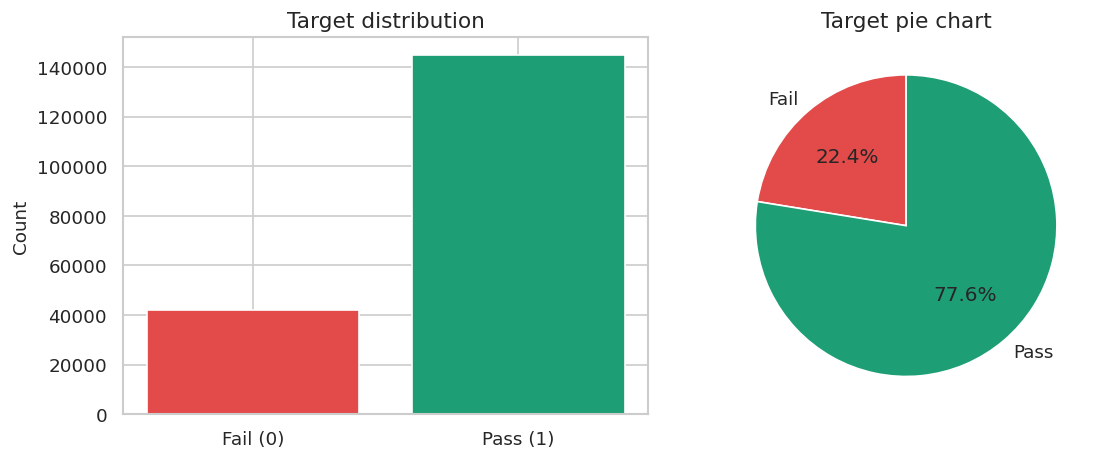

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# ── CELL 3 │ Basic EDA — dtypes, missing values, target distribution
# ══════════════════════════════════════════════════════════════════════════════

# Define target column
TARGET_COL = 'target'

print("=" * 55)
print("DTYPES")
print("=" * 55)
print(train.dtypes)

print("\n" + "=" * 55)
print("MISSING VALUES")
print("=" * 55)
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(2)
missing_df = pd.DataFrame({"count": missing, "pct": missing_pct})
print(missing_df[missing_df["count"] > 0])

print("\n" + "=" * 55)
print("TARGET DISTRIBUTION")
print("=" * 55)
vc = train[TARGET_COL].value_counts()
print(vc)
print(f"\nClass ratio (pass/fail): {vc[1] / vc[0]:.2f} : 1")
print(f"Fail rate: {vc[0] / len(train):.2%}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(["Fail (0)", "Pass (1)"], [vc[0], vc[1]], color=["#E24B4A", "#1D9E75"])
axes[0].set_title("Target distribution")
axes[0].set_ylabel("Count")
axes[1].pie([vc[0], vc[1]], labels=["Fail", "Pass"],
            colors=["#E24B4A", "#1D9E75"], autopct="%1.1f%%", startangle=90)
axes[1].set_title("Target pie chart")
plt.tight_layout()
plt.show()

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# ── CELL 4 │ Parse Violation_List
# ══════════════════════════════════════════════════════════════════════════════
def parse_violations(v):
    try:
        codes = ast.literal_eval(v)
        return [str(int(c)) if str(c).isdigit() else str(c).strip()
                for c in codes]
    except Exception:
        return []

train["violations"] = train["Violation_List"].apply(parse_violations)
test["violations"]  = test["Violation_List"].apply(parse_violations)

print("Sample parsed violations:")
print(train["violations"].head(5).tolist())
print(f"\nRows with 0 violations: {(train['violations'].apply(len) == 0).sum():,}")

Sample parsed violations:
[[], ['3', '10', '5', '5', '16', '23', '5', '25', '5', '38', '51', '55', '56'], ['10', '35', '39', '55'], ['2', '12', '5', '5', '10', '47', '47', '51', '54', '56'], ['30', '32', '36', '38']]

Rows with 0 violations: 30,869


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# ── CELL 5 │ Build violation lookup tables
# ══════════════════════════════════════════════════════════════════════════════
records = []
for _, row in train.iterrows():
    for code in row["violations"]:
        records.append({"code": code, "target": row[TARGET_COL]})

viol_df = pd.DataFrame(records)

code_stats = (viol_df.groupby("code")[TARGET_COL]
              .agg(total="count", passes="sum")
              .assign(fails=lambda d: d["total"] - d["passes"],
                      fail_rate=lambda d: (d["total"] - d["passes"]) / d["total"])
              .reset_index()
              .sort_values("total", ascending=False))

print("Top 15 violation codes by total appearances:")
print(code_stats.head(15).to_string(index=False))


Top 15 violation codes by total appearances:
code  total  passes  fails  fail_rate
  55  59370   39683  19687   0.331598
  38  54187   32361  21826   0.402790
  34  50204   36558  13646   0.271811
  33  47167   33977  13190   0.279645
  35  46119   33002  13117   0.284416
  32  38876   28146  10730   0.276006
   5  33766   19698  14068   0.416632
  41  30002   19976  10026   0.334178
  47  29943   19992   9951   0.332331
  10  27222   14172  13050   0.479392
  36  25017   16370   8647   0.345645
  49  23748   15374   8374   0.352619
  51  21736   14314   7422   0.341461
   3  19714   12441   7273   0.368926
  56  17856   11818   6038   0.338150


Q1 — Top 10 violation codes by failure rate (min 100 appearances):
code  total  fails  fail_rate
  18  12296  11872   0.965517
  24   2562   2324   0.907104
  20   5664   5095   0.899541
  26   1124   1005   0.894128
  19   3325   2966   0.892030
2016    181    161   0.889503
2017    142    123   0.866197
  29   5257   4501   0.856192
 404    533    439   0.823640
2024    172    141   0.819767


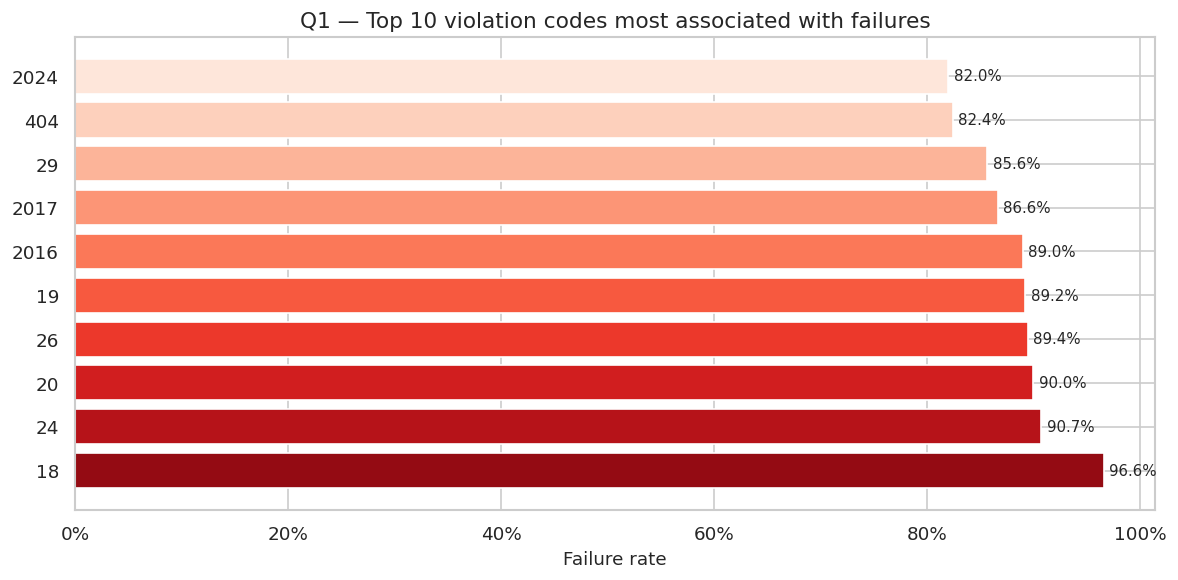

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# ── CELL 6 │ REQUIRED QUESTION 1
#   Top 10 violation codes most associated with FAILED inspections
# ══════════════════════════════════════════════════════════════════════════════
stable = code_stats[code_stats["total"] >= 100].copy()
top10_fail = stable.nlargest(10, "fail_rate")

print("Q1 — Top 10 violation codes by failure rate (min 100 appearances):")
print(top10_fail[["code", "total", "fails", "fail_rate"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette("Reds_r", len(top10_fail))
bars = ax.barh(top10_fail["code"].astype(str),
               top10_fail["fail_rate"], color=colors)
ax.set_xlabel("Failure rate")
ax.set_title("Q1 — Top 10 violation codes most associated with failures")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
for bar, rate in zip(bars, top10_fail["fail_rate"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{rate:.1%}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

Q2 — Facility types by total violation codes triggered:
                                 total_violations  avg_violations  inspection_count
Facility Type                                                                      
Restaurant                                 645651        5.091162            126818
Grocery Store                              111665        4.940055             22604
School                                      46494        3.504221             13268
Children's Services Facility                14920        3.066173              4866
Bakery                                      14136        5.318284              2658
Daycare Above and Under 2 Years              9330        3.473567              2686
Long Term Care                               8097        5.150763              1572
Daycare (2 - 6 Years)                        5876        2.938000              2000
Catering                                     4360        4.228904              1031
Other               

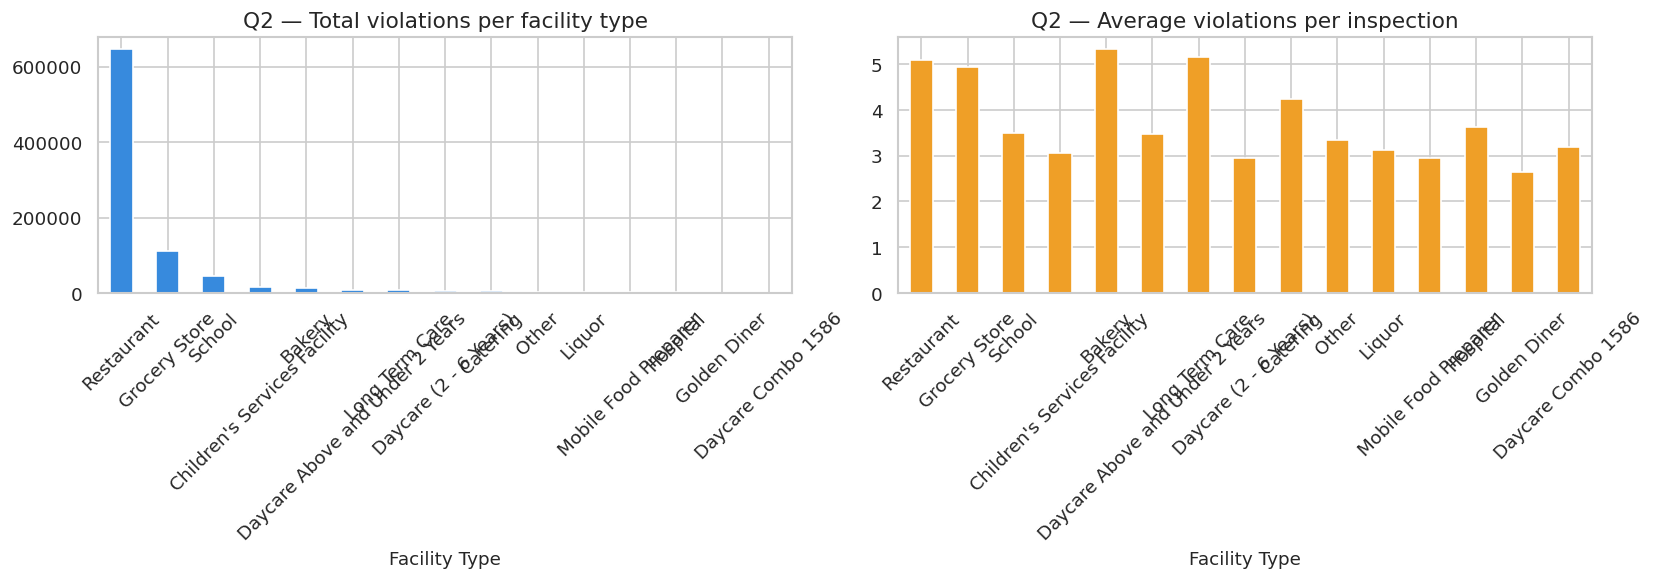

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# ── CELL 7 │ REQUIRED QUESTION 2
#   Which Facility Type violates the highest number of codes?
# ══════════════════════════════════════════════════════════════════════════════
train["viol_count"] = train["violations"].apply(len)

facility_viol = (train.groupby("Facility Type")["viol_count"]
                 .agg(total_violations="sum", avg_violations="mean",
                      inspection_count="count")
                 .sort_values("total_violations", ascending=False)
                 .head(15))

print("Q2 — Facility types by total violation codes triggered:")
print(facility_viol.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
facility_viol["total_violations"].plot(kind="bar", ax=axes[0],
                                       color="#378ADD", edgecolor="white")
axes[0].set_title("Q2 — Total violations per facility type")
axes[0].tick_params(axis="x", rotation=45)

facility_viol["avg_violations"].plot(kind="bar", ax=axes[1],
                                     color="#EF9F27", edgecolor="white")
axes[1].set_title("Q2 — Average violations per inspection")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


Q3 — Failure rate by risk category:
           Risk  total  passes  fails  fail_rate
            All      5       0      5   1.000000
   Risk 3 (Low)  12114    8624   3490   0.288096
Risk 2 (Medium)  32807   25420   7387   0.225165
  Risk 1 (High) 141706  110714  30992   0.218706


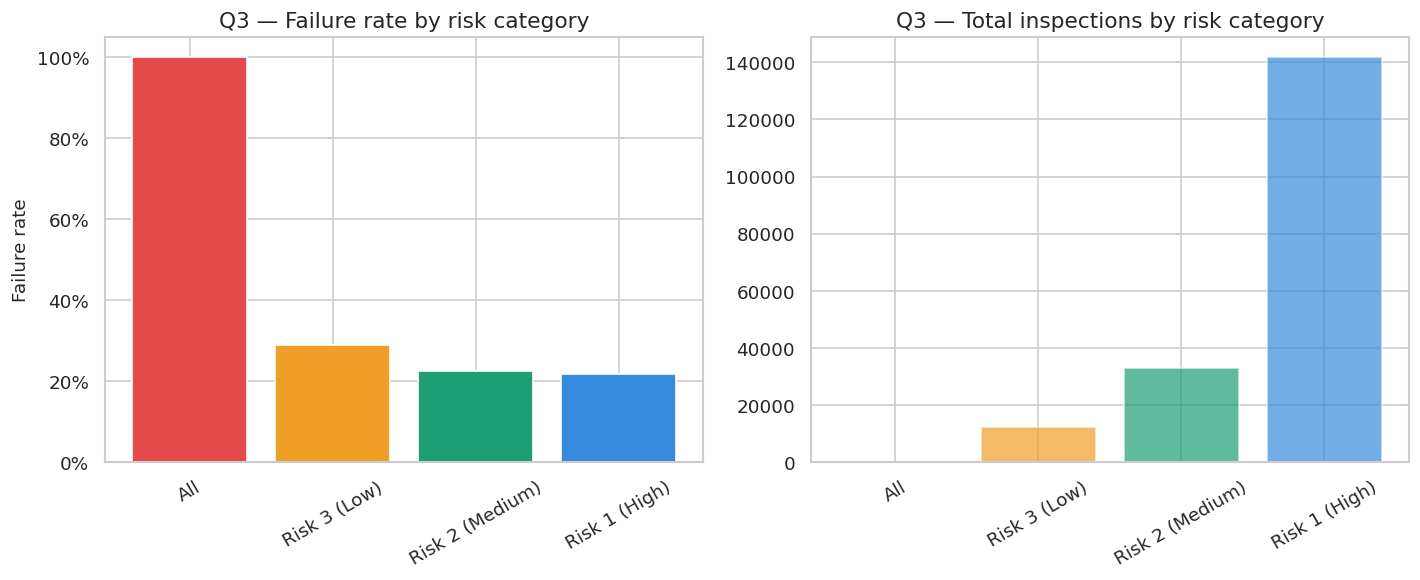

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# ── CELL 8 │ REQUIRED QUESTION 3
#   Which risk category has the highest failure rate?
# ══════════════════════════════════════════════════════════════════════════════
risk_stats = (train.groupby("Risk")[TARGET_COL]
              .agg(total="count", passes="sum")
              .assign(fails=lambda d: d["total"] - d["passes"],
                      fail_rate=lambda d: (d["total"] - d["passes"]) / d["total"])
              .reset_index()
              .sort_values("fail_rate", ascending=False))

print("Q3 — Failure rate by risk category:")
print(risk_stats.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ["#E24B4A", "#EF9F27", "#1D9E75", "#378ADD"]
axes[0].bar(risk_stats["Risk"], risk_stats["fail_rate"], color=colors)
axes[0].set_title("Q3 — Failure rate by risk category")
axes[0].set_ylabel("Failure rate")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(risk_stats["Risk"], risk_stats["total"], color=colors, alpha=0.7)
axes[1].set_title("Q3 — Total inspections by risk category")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

Q4 — Failed inspections by month:
  Jan: 3,416
  Feb: 3,201
  Mar: 3,790
  Apr: 3,815
  May: 3,815
  Jun: 3,659
  Jul: 3,202
  Aug: 3,871
  Sep: 3,792
  Oct: 3,769
  Nov: 2,996
  Dec: 2,564

Q4 — Failed inspections by weekday (0=Mon):
  Mon: 7,215
  Tue: 9,882
  Wed: 7,637
  Thu: 9,387
  Fri: 7,750
  Sat: 17
  Sun: 2


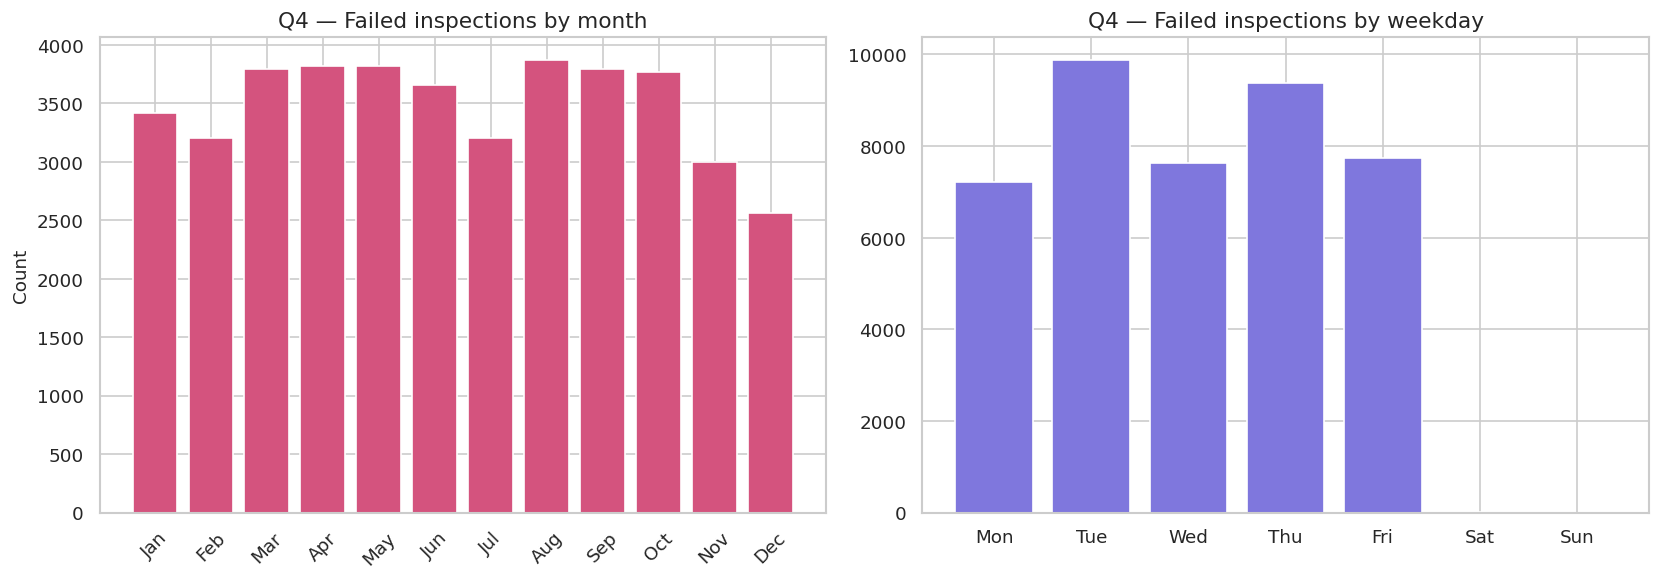

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# ── CELL 9 │ REQUIRED QUESTION 4
#   Which months or weekdays have the most failed inspections?
# ══════════════════════════════════════════════════════════════════════════════
failed = train[train[TARGET_COL] == 0]

month_fail   = failed["month"].value_counts().sort_index()
weekday_fail = failed["weekday"].value_counts().sort_index()

month_names   = ["Jan","Feb","Mar","Apr","May","Jun",
                 "Jul","Aug","Sep","Oct","Nov","Dec"]
weekday_names = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

print("Q4 — Failed inspections by month:")
for m, c in month_fail.items():
    print(f"  {month_names[m-1]}: {c:,}")

print("\nQ4 — Failed inspections by weekday (0=Mon):")
for d, c in weekday_fail.items():
    name = weekday_names[d] if d < len(weekday_names) else str(d)
    print(f"  {name}: {c:,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar([month_names[m - 1] for m in month_fail.index],
            month_fail.values, color="#D4537E", edgecolor="white")
axes[0].set_title("Q4 — Failed inspections by month")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar([weekday_names[d] if d < len(weekday_names) else str(d)
             for d in weekday_fail.index],
            weekday_fail.values, color="#7F77DD", edgecolor="white")
axes[1].set_title("Q4 — Failed inspections by weekday")
plt.tight_layout()
plt.show()

Q5 — Top 15 cities by failure rate (min 200 inspections):
   City  total  fail_rate
CHICAGO 185898   0.224456
Chicago    316   0.189873


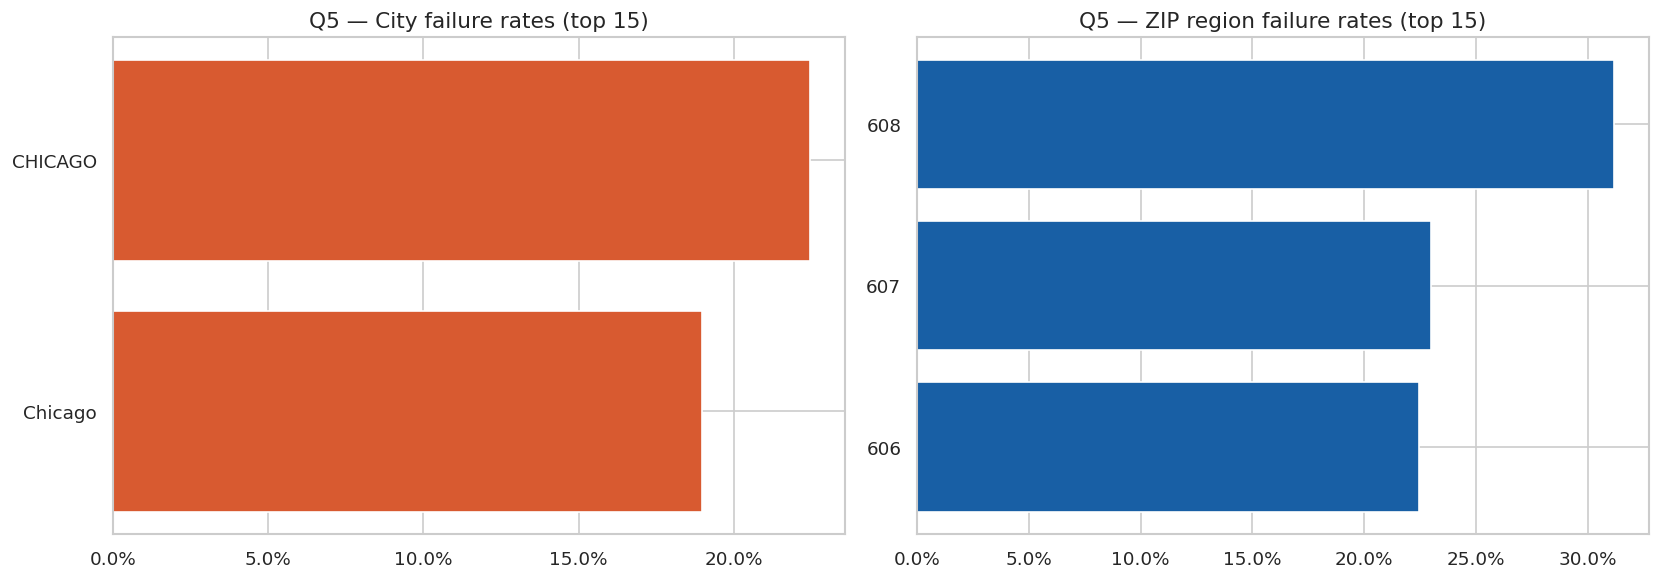

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# ── CELL 10 │ REQUIRED QUESTION 5
#   Compare inspection outcomes across different cities / ZIP regions
# ══════════════════════════════════════════════════════════════════════════════
city_stats = (train.groupby("City")[TARGET_COL]
              .agg(total="count", passes="sum")
              .assign(fail_rate=lambda d: (d["total"] - d["passes"]) / d["total"])
              .query("total >= 200")
              .sort_values("fail_rate", ascending=False)
              .reset_index())

print("Q5 — Top 15 cities by failure rate (min 200 inspections):")
print(city_stats.head(15)[["City", "total", "fail_rate"]].to_string(index=False))

train["zip_region"] = train["Zip"].astype(str).str[:3]
zip_stats = (train.groupby("zip_region")[TARGET_COL]
             .agg(total="count", passes="sum")
             .assign(fail_rate=lambda d: (d["total"] - d["passes"]) / d["total"])
             .query("total >= 100")
             .sort_values("fail_rate", ascending=False)
             .head(15)
             .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_cities = city_stats.head(15)
axes[0].barh(top_cities["City"], top_cities["fail_rate"],
             color="#D85A30", edgecolor="white")
axes[0].set_title("Q5 — City failure rates (top 15)")
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].invert_yaxis()

axes[1].barh(zip_stats["zip_region"], zip_stats["fail_rate"],
             color="#185FA5", edgecolor="white")
axes[1].set_title("Q5 — ZIP region failure rates (top 15)")
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()


Q6 — Failure rate by number of violations:
 viol_count  total  passes  fail_rate
          0  30869   28317   0.082672
          1  17806   16782   0.057509
          2  23198   21362   0.079145
          3  22030   19304   0.123740
          4  19928   16385   0.177790
          5  15304   11457   0.251372
          6  12360    8528   0.310032
          7   8897    5290   0.405418
          8   7093    3985   0.438178
          9   5326    2696   0.493804
         10   4312    2222   0.484694
         11   3299    1533   0.535314
         12   2843    1403   0.506507
         13   2129     953   0.552372
         14   1967     902   0.541434
         15   1376     547   0.602471
         16   1332     601   0.548799
         17    952     359   0.622899
         18    923     408   0.557963
         19    701     264   0.623395
         20    654     273   0.582569
         21    486     165   0.660494
         22    435     168   0.613793
         23    324     101   0.688272
       

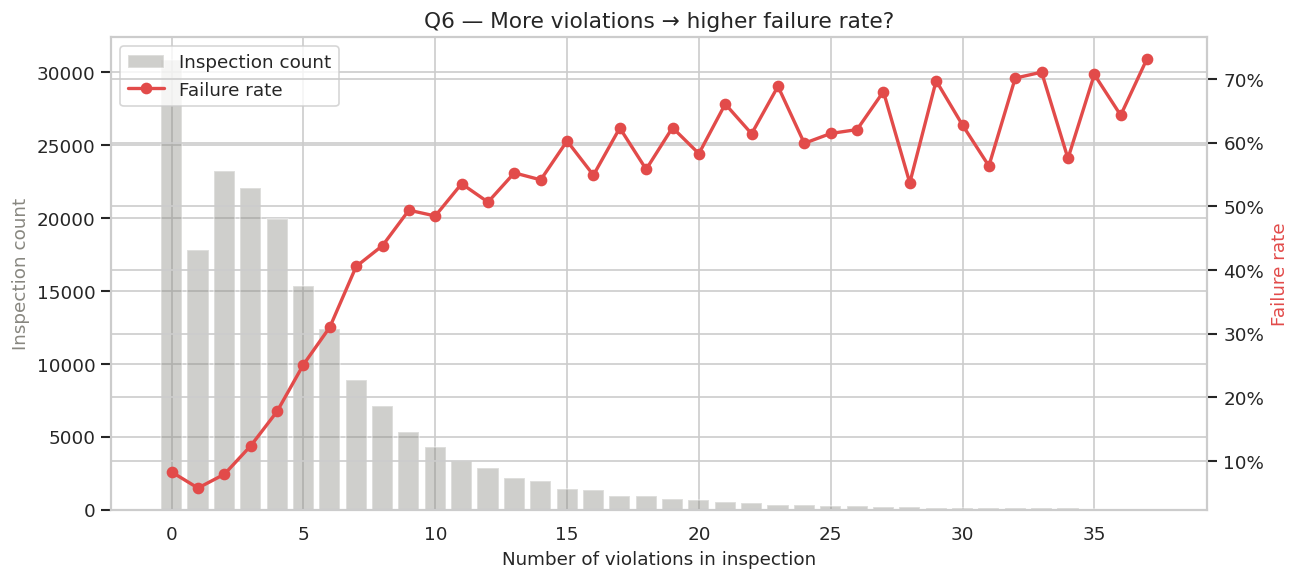

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# ── CELL 11 │ REQUIRED QUESTION 6
#   Do establishments with more violations fail more?
# ══════════════════════════════════════════════════════════════════════════════
viol_outcome = (train.groupby("viol_count")[TARGET_COL]
                .agg(total="count", passes="sum")
                .assign(fail_rate=lambda d: (d["total"] - d["passes"]) / d["total"])
                .query("total >= 30")
                .reset_index())

print("Q6 — Failure rate by number of violations:")
print(viol_outcome.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5))
ax2 = ax.twinx()
ax.bar(viol_outcome["viol_count"], viol_outcome["total"],
       alpha=0.4, color="#888780", label="Inspection count")
ax2.plot(viol_outcome["viol_count"], viol_outcome["fail_rate"],
         color="#E24B4A", marker="o", linewidth=2, label="Failure rate")
ax.set_xlabel("Number of violations in inspection")
ax.set_ylabel("Inspection count", color="#888780")
ax2.set_ylabel("Failure rate", color="#E24B4A")
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_title("Q6 — More violations → higher failure rate?")
lines1, l1 = ax.get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, l1 + l2, loc="upper left")
plt.tight_layout()
plt.show()



Restaurant — top 5 violations:
Facility Type code  count
   Restaurant   55  40672
   Restaurant   38  35832
   Restaurant   33  34921
   Restaurant   34  34379
   Restaurant   35  30789

Grocery Store — top 5 violations:
Facility Type code  count
Grocery Store   55   8077
Grocery Store   34   7529
Grocery Store   38   7294
Grocery Store   35   6446
Grocery Store   33   6091

School — top 5 violations:
Facility Type code  count
       School   38   4889
       School   35   4017
       School   55   3456
       School   34   3404
       School   10   2318

Children's Services Facility — top 5 violations:
               Facility Type code  count
Children's Services Facility   55   1835
Children's Services Facility   38   1062
Children's Services Facility    5    778
Children's Services Facility   35    729
Children's Services Facility   34    631

Daycare Above and Under 2 Years — top 5 violations:
                  Facility Type code  count
Daycare Above and Under 2 Years   55   1169


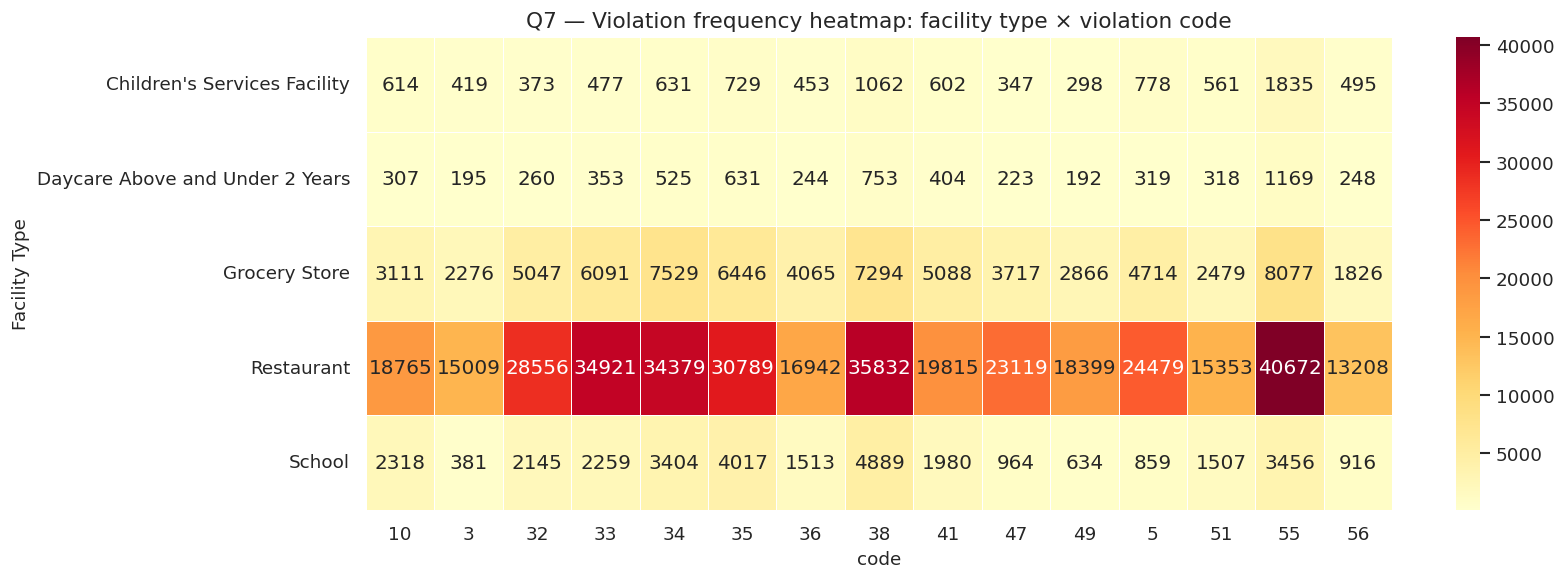

In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# ── CELL 12 │ REQUIRED QUESTION 7
#   Most common violations among different facility types
# ══════════════════════════════════════════════════════════════════════════════
top_facilities = train["Facility Type"].value_counts().head(5).index.tolist()

rows = []
for _, row in train[train["Facility Type"].isin(top_facilities)].iterrows():
    for code in row["violations"]:
        rows.append({"Facility Type": row["Facility Type"], "code": code})

fac_viol_df = pd.DataFrame(rows)
pivot = (fac_viol_df.groupby(["Facility Type", "code"])
         .size()
         .reset_index(name="count"))

for fac in top_facilities:
    sub_df = pivot[pivot["Facility Type"] == fac].nlargest(5, "count")
    print(f"\n{fac} — top 5 violations:")
    print(sub_df.to_string(index=False))

top_codes_global = code_stats["code"].head(15).tolist()
heatmap_data = (pivot[pivot["code"].isin(top_codes_global)]
                .pivot_table(index="Facility Type", columns="code",
                             values="count", fill_value=0))

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heatmap_data, annot=True, fmt="g", cmap="YlOrRd",
            linewidths=0.3, ax=ax)
ax.set_title("Q7 — Violation frequency heatmap: facility type × violation code")
plt.tight_layout()
plt.show()

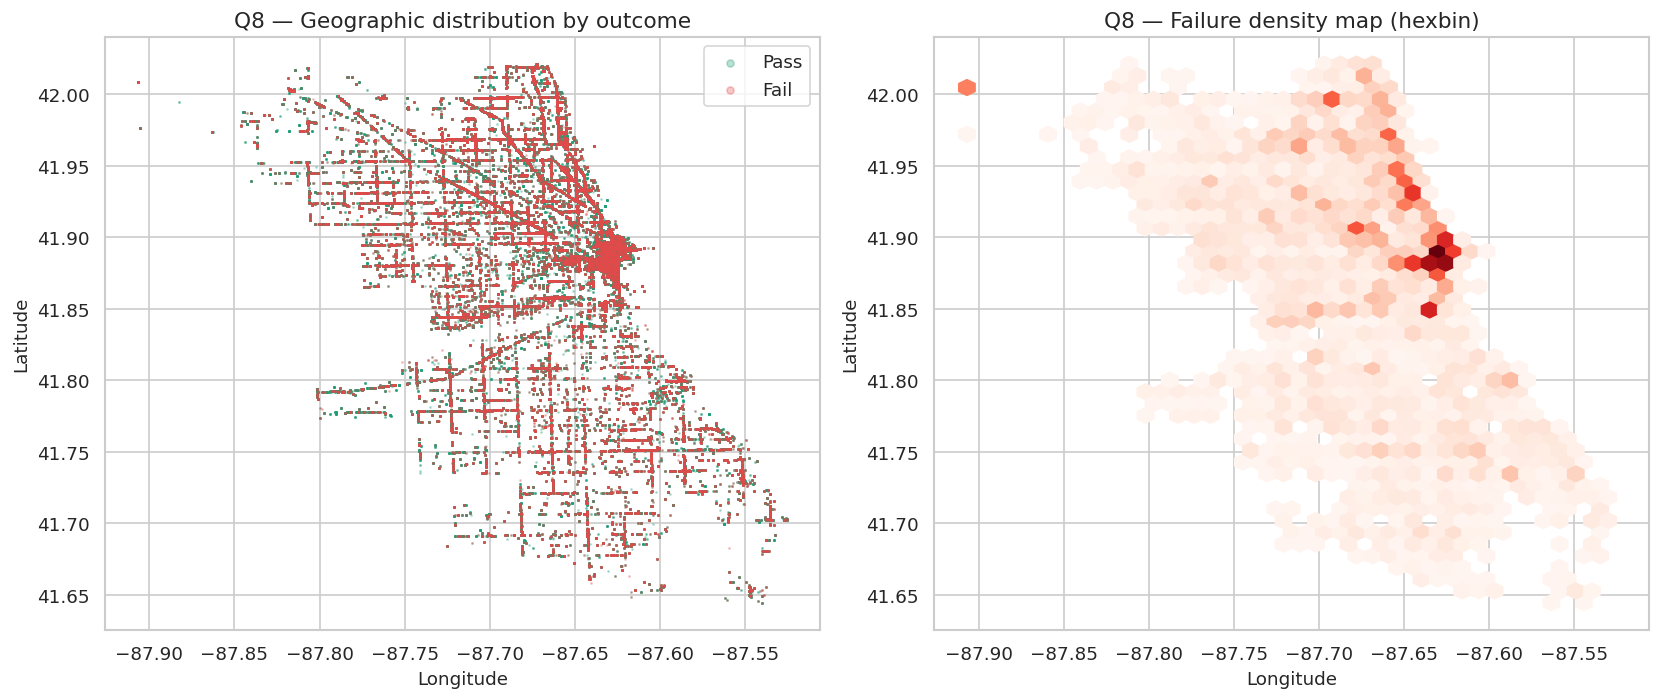

Coverage: 185,969 / 186,655 rows have valid coordinates


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# ── CELL 13 │ REQUIRED QUESTION 8
#   Geographic trends using latitude and longitude
# ══════════════════════════════════════════════════════════════════════════════
geo = train.dropna(subset=["Latitude", "Longitude"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
pass_geo = geo[geo[TARGET_COL] == 1]
fail_geo = geo[geo[TARGET_COL] == 0]
axes[0].scatter(pass_geo["Longitude"], pass_geo["Latitude"],
                s=0.5, alpha=0.3, c="#1D9E75", label="Pass")
axes[0].scatter(fail_geo["Longitude"], fail_geo["Latitude"],
                s=0.5, alpha=0.3, c="#E24B4A", label="Fail")
axes[0].set_title("Q8 — Geographic distribution by outcome")
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")
axes[0].legend(markerscale=6)

axes[1].hexbin(fail_geo["Longitude"], fail_geo["Latitude"],
               gridsize=40, cmap="Reds", mincnt=1)
axes[1].set_title("Q8 — Failure density map (hexbin)")
axes[1].set_xlabel("Longitude"); axes[1].set_ylabel("Latitude")
plt.tight_layout()
plt.show()
print(f"Coverage: {len(geo):,} / {len(train):,} rows have valid coordinates")


Q9 — Failure rate by inspection type:
         insp_type_clean  total  passes  fail_rate
              Task Force    186      90   0.516129
                 License  25917   16922   0.347069
               Complaint  25707   18031   0.298596
                   Other    756     552   0.269841
                 Canvass  91257   70666   0.225637
Suspected Food Poisoning    865     671   0.224277
            Consultation    448     366   0.183036
 Complaint Re-Inspection   8709    7673   0.118957
   License Re-Inspection   8754    7808   0.108065
   Canvass Re-Inspection  23634   21585   0.086697
             Tag Removal    422     401   0.049763


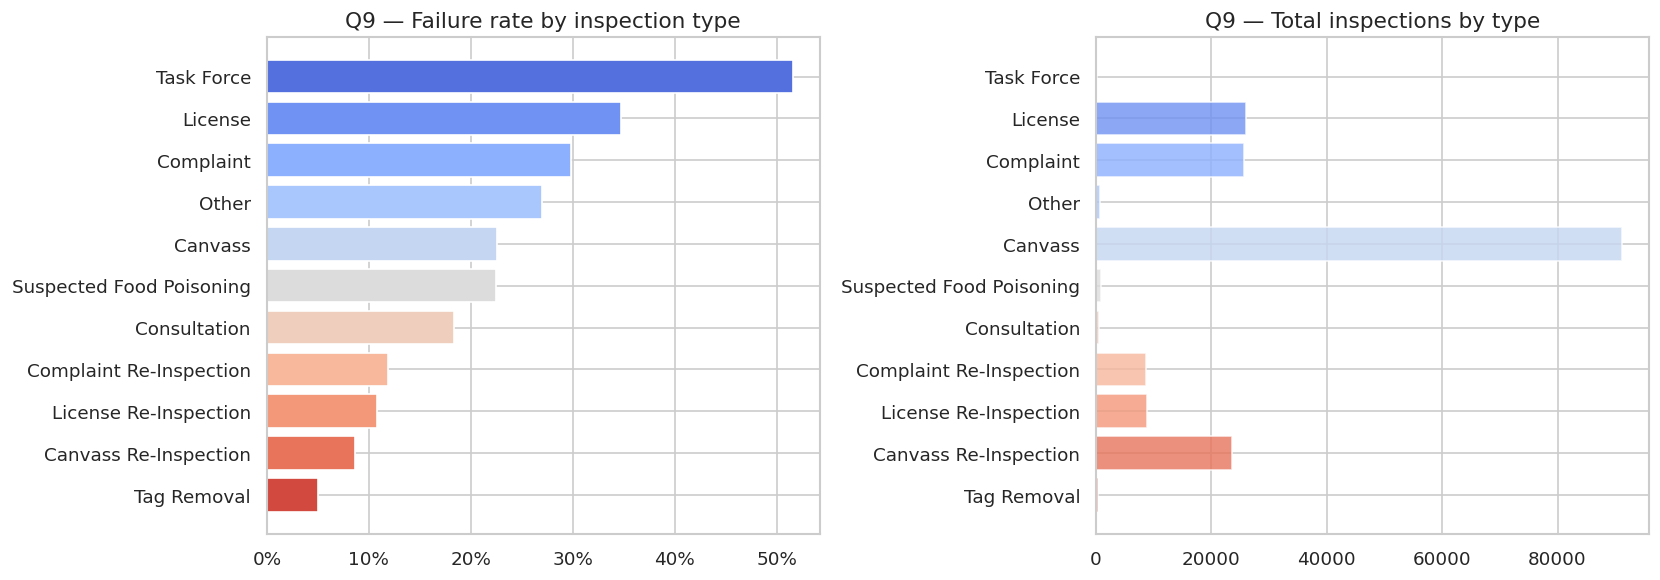

In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# ── CELL 14 │ REQUIRED QUESTION 9
#   Inspection type vs inspection outcome
# ══════════════════════════════════════════════════════════════════════════════
def normalise_insp_type(s):
    if pd.isna(s): return "Unknown"
    s = s.strip().upper()
    if "CANVASS" in s and "RE" in s:      return "Canvass Re-Inspection"
    if "CANVASS" in s:                    return "Canvass"
    if "COMPLAINT" in s and "RE" in s:    return "Complaint Re-Inspection"
    if "COMPLAINT" in s:                  return "Complaint"
    if "LICENSE" in s and "RE" in s:      return "License Re-Inspection"
    if "LICENSE" in s:                    return "License"
    if "FOOD POISONING" in s or "SFP" in s: return "Suspected Food Poisoning"
    if "TASK FORCE" in s or "TASKFORCE" in s: return "Task Force"
    if "SHORT FORM" in s:                 return "Short Form Complaint"
    if "CONSULTATION" in s:               return "Consultation"
    if "TAG REMOVAL" in s:                return "Tag Removal"
    return "Other"

train["insp_type_clean"] = train["Inspection Type"].apply(normalise_insp_type)
test["insp_type_clean"]  = test["Inspection Type"].apply(normalise_insp_type)

insp_stats = (train.groupby("insp_type_clean")[TARGET_COL]
              .agg(total="count", passes="sum")
              .assign(fail_rate=lambda d: (d["total"] - d["passes"]) / d["total"])
              .sort_values("fail_rate", ascending=False)
              .reset_index())

print("Q9 — Failure rate by inspection type:")
print(insp_stats.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = sns.color_palette("coolwarm", len(insp_stats))
axes[0].barh(insp_stats["insp_type_clean"], insp_stats["fail_rate"], color=colors)
axes[0].set_title("Q9 — Failure rate by inspection type")
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].invert_yaxis()
axes[1].barh(insp_stats["insp_type_clean"], insp_stats["total"],
             color=colors, alpha=0.8)
axes[1].set_title("Q9 — Total inspections by type")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

Building violation binary matrix...

Q10 — Violation codes as indicators of failure (chi2 score):
code   chi2_score  fail_rate
  18 38444.818392   0.965517
  20 13602.217891   0.899541
  29 11302.500288   0.856192
  19  8452.349040   0.892030
  90  7999.243617   0.771013
  60  7049.833103   0.698327
  16  7031.266663   0.585465
  38  7018.530033   0.402790
  48  6358.035388   0.595226
  10  5341.010900   0.479392
   2  4903.388682   0.485940
  11  4808.874777   0.710739
  54  3649.139748   0.574435
   5  3251.409795   0.416632
  22  3022.808059   0.536947


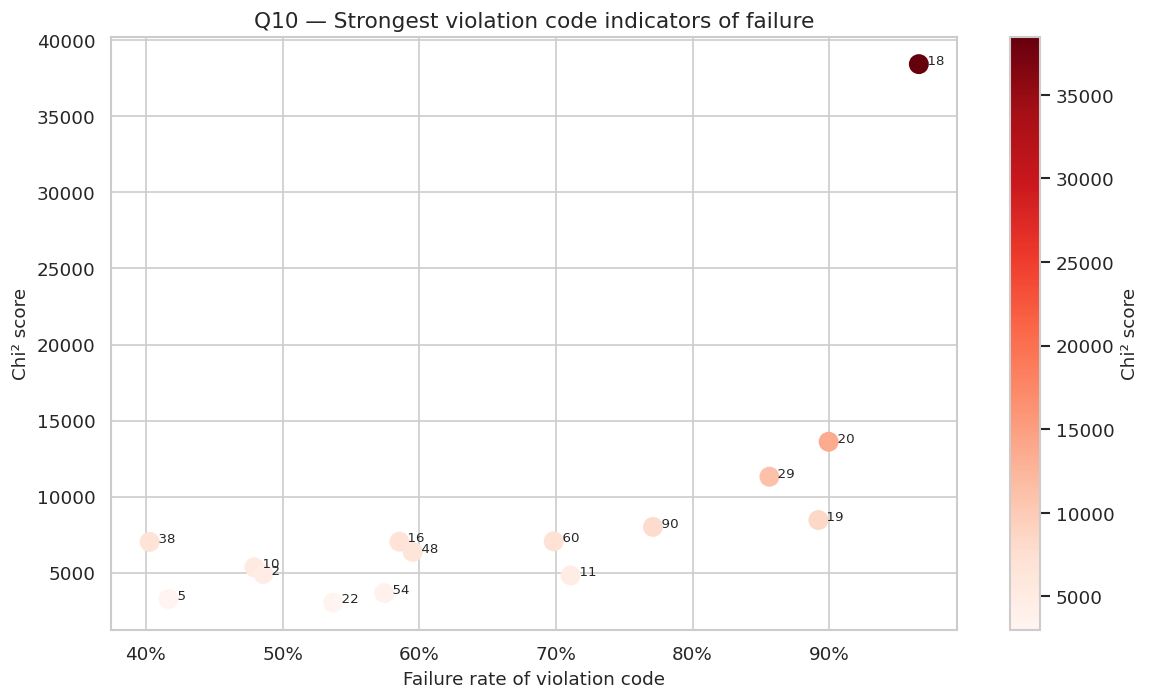

In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# ── CELL 15 │ REQUIRED QUESTION 10
#   Strongest violation code indicators of failure (chi2)
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.feature_selection import chi2 as chi2_stat
from sklearn.preprocessing import MinMaxScaler

top_codes_q10 = code_stats["code"].head(50).tolist()

def make_viol_matrix(df, codes):
    mat = pd.DataFrame(0, index=df.index, columns=codes)
    for idx, row in df.iterrows():
        for c in row["violations"]:
            if c in codes:
                mat.at[idx, c] = 1
    return mat

print("Building violation binary matrix...")
viol_matrix = make_viol_matrix(train, top_codes_q10)

y_q10 = train[TARGET_COL].values
chi2_scores, _ = chi2_stat(viol_matrix, 1 - y_q10)
chi2_df = pd.DataFrame({"code": top_codes_q10, "chi2_score": chi2_scores})
chi2_df = chi2_df.merge(code_stats[["code", "fail_rate"]], on="code")
chi2_df = chi2_df.sort_values("chi2_score", ascending=False).head(15)

print("\nQ10 — Violation codes as indicators of failure (chi2 score):")
print(chi2_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(chi2_df["fail_rate"], chi2_df["chi2_score"],
                s=120, c=chi2_df["chi2_score"], cmap="Reds", zorder=3)
for _, row in chi2_df.iterrows():
    ax.annotate(f"  {row['code']}", (row["fail_rate"], row["chi2_score"]), fontsize=8)
ax.set_xlabel("Failure rate of violation code")
ax.set_ylabel("Chi² score")
ax.set_title("Q10 — Strongest violation code indicators of failure")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.colorbar(sc, ax=ax, label="Chi² score")
plt.tight_layout()
plt.show()

In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# ── CELL 16 │ IMPROVED Feature Engineering
# ══════════════════════════════════════════════════════════════════════════════
combined = pd.concat([train.drop(columns=[TARGET_COL], errors="ignore"),
                      test], ignore_index=True)
y = train[TARGET_COL].values

# ── 16a. Violation features ──────────────────────────────────────────────────
combined["violations"] = combined["Violation_List"].apply(parse_violations)
combined["viol_count"] = combined["violations"].apply(len)
combined["viol_unique_count"] = combined["violations"].apply(lambda x: len(set(x)))
combined["has_zero_violations"] = (combined["viol_count"] == 0).astype(int)

# ✨ NEW: ratio of unique codes to total (repetition metric)
combined["viol_repeat_ratio"] = combined["viol_count"] / (combined["viol_unique_count"] + 1)

# Top-60 violation codes as binary flags (was 40)
TOP_N_CODES = 60
top60_codes = code_stats["code"].head(TOP_N_CODES).tolist()
for code in top60_codes:
    col = f"viol_{code}"
    combined[col] = combined["violations"].apply(lambda lst: int(code in lst))

# Weighted failure score
fail_rate_map = code_stats.set_index("code")["fail_rate"].to_dict()
combined["viol_failure_score"] = combined["violations"].apply(
    lambda lst: sum(fail_rate_map.get(c, 0) for c in lst))

# ✨ NEW: max single-code failure rate in this inspection
combined["viol_max_fail_rate"] = combined["violations"].apply(
    lambda lst: max((fail_rate_map.get(c, 0) for c in lst), default=0))

# ✨ NEW: number of "high-risk" violation codes (fail rate > 0.5)
high_risk_codes_set = set(code_stats[code_stats["fail_rate"] > 0.5]["code"].tolist())
combined["viol_high_risk_count"] = combined["violations"].apply(
    lambda lst: sum(1 for c in lst if c in high_risk_codes_set))

# ✨ NEW: count of violations that are in top-10 fail indicators
top10_codes_set = set(top10_fail["code"].tolist())
combined["viol_top10_fail_count"] = combined["violations"].apply(
    lambda lst: sum(1 for c in lst if c in top10_codes_set))

print("Violation features created ✓")

# ── 16b. Categorical features ────────────────────────────────────────────────
combined["insp_type_clean"] = combined["Inspection Type"].apply(normalise_insp_type)
combined["is_reinspection"] = combined["insp_type_clean"].str.contains(
    "Re-Inspection").astype(int)

risk_order = {"Risk 1 (High)": 3, "Risk 2 (Medium)": 2,
              "Risk 3 (Low)": 1, "All": 0}
combined["risk_ordinal"] = combined["Risk"].map(risk_order).fillna(0)

combined["City"] = combined["City"].fillna("UNKNOWN").str.strip().str.upper()
city_counts = combined["City"].value_counts()
rare_cities = city_counts[city_counts < 30].index
combined["City"] = combined["City"].replace(rare_cities, "OTHER")

combined["zip_region"] = combined["Zip"].astype(str).str[:3]

# Label encode
label_cols = ["Facility Type", "City", "State", "insp_type_clean",
              "zip_region", "Risk"]
for col in label_cols:
    combined[col] = combined[col].fillna("UNKNOWN")
    le = LabelEncoder()
    combined[col + "_enc"] = le.fit_transform(combined[col].astype(str))

print("Categorical features created ✓")

# ── 16c. Temporal features ───────────────────────────────────────────────────
combined["is_weekend"]  = (combined["weekday"] >= 5).astype(int)
combined["quarter"]     = ((combined["month"] - 1) // 3 + 1)
combined["year_norm"]   = combined["year"] - combined["year"].min()
combined["month_sin"]   = np.sin(2 * np.pi * combined["month"] / 12)
combined["month_cos"]   = np.cos(2 * np.pi * combined["month"] / 12)
combined["day_sin"]     = np.sin(2 * np.pi * combined["weekday"] / 7)
combined["day_cos"]     = np.cos(2 * np.pi * combined["weekday"] / 7)

print("Temporal features created ✓")

# ── 16d. Geographic features ─────────────────────────────────────────────────
lat_median = combined["Latitude"].median()
lon_median = combined["Longitude"].median()
combined["Latitude"]  = combined["Latitude"].fillna(lat_median)
combined["Longitude"] = combined["Longitude"].fillna(lon_median)

CHI_LAT, CHI_LON = 41.8781, -87.6298
combined["dist_from_center"] = np.sqrt(
    (combined["Latitude"]  - CHI_LAT) ** 2 +
    (combined["Longitude"] - CHI_LON) ** 2)

# ✨ NEW: lat/lon binned cluster
combined["lat_bin"] = pd.cut(combined["Latitude"],  bins=20, labels=False)
combined["lon_bin"] = pd.cut(combined["Longitude"], bins=20, labels=False)

print("Geographic features created ✓")

# ── 16e. Interaction features ────────────────────────────────────────────────
# ✨ NEW: Risk × violation interaction
combined["risk_x_viol_count"]   = combined["risk_ordinal"] * combined["viol_count"]
combined["risk_x_fail_score"]   = combined["risk_ordinal"] * combined["viol_failure_score"]
combined["risk_x_high_risk_viol"] = combined["risk_ordinal"] * combined["viol_high_risk_count"]

# ✨ NEW: viol_count squared (captures non-linearity)
combined["viol_count_sq"] = combined["viol_count"] ** 2

# ✨ NEW: has high-risk violation flag
combined["has_high_risk_viol"] = (combined["viol_high_risk_count"] > 0).astype(int)

print("Interaction features created ✓")

Violation features created ✓
Categorical features created ✓
Temporal features created ✓
Geographic features created ✓
Interaction features created ✓


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# ── CELL 17 │ TARGET ENCODING (✨ KEY IMPROVEMENT — replaces label encoding)
#   Uses out-of-fold means to prevent leakage
# ══════════════════════════════════════════════════════════════════════════════

# Define required variables
TARGET_ENC_COLS = ["Facility Type", "City", "zip_region", "insp_type_clean", "Risk"]
TRAIN_LEN = len(train)  # Number of rows in training set
GLOBAL_MEAN = y.mean()

def target_encode_oof(combined_df, train_len, y_train,
                      cols, n_splits=5, smooth=20, seed=42):
    """
    Out-of-fold target encoding on train; global-smoothed mean on test.
    smooth: smoothing parameter — higher = more regularisation.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    global_mean = y_train.mean()
    te_train = np.full(train_len, np.nan)
    te_test  = np.zeros(len(combined_df) - train_len)
    train_df = combined_df.iloc[:train_len].copy()
    test_df  = combined_df.iloc[train_len:].copy()
    te_cols = {}
    
    for col in cols:
        new_col = col + "_te"
        te_train_col = np.full(train_len, np.nan)
        
        for trn_idx, val_idx in skf.split(train_df, y_train):
            # compute mean on training fold
            fold_map = (train_df.iloc[trn_idx]
                        .assign(_y=y_train[trn_idx])
                        .groupby(col)["_y"]
                        .agg(["mean", "count"]))
            # smoothed mean: (count * mean + smooth * global_mean) / (count + smooth)
            fold_map["smooth"] = (
                (fold_map["count"] * fold_map["mean"] + smooth * global_mean)
                / (fold_map["count"] + smooth)
            )
            val_vals = train_df.iloc[val_idx][col].map(fold_map["smooth"])
            te_train_col[val_idx] = val_vals.fillna(global_mean).values
        
        # For test: use full training set mean (smoothed)
        full_map = (train_df.assign(_y=y_train)
                    .groupby(col)["_y"]
                    .agg(["mean", "count"]))
        full_map["smooth"] = (
            (full_map["count"] * full_map["mean"] + smooth * global_mean)
            / (full_map["count"] + smooth)
        )
        te_test_col = test_df[col].map(full_map["smooth"]).fillna(global_mean).values
        combined_df[new_col] = np.concatenate([te_train_col, te_test_col])
        print(f"  Target-encoded '{col}' → '{new_col}'")
    
    return combined_df

print("Applying target encoding (OOF to avoid leakage)...")
combined = target_encode_oof(combined, TRAIN_LEN, y,
                             TARGET_ENC_COLS, n_splits=5, smooth=20)
print("Target encoding complete ✓")

Applying target encoding (OOF to avoid leakage)...
  Target-encoded 'Facility Type' → 'Facility Type_te'
  Target-encoded 'City' → 'City_te'
  Target-encoded 'zip_region' → 'zip_region_te'
  Target-encoded 'insp_type_clean' → 'insp_type_clean_te'
  Target-encoded 'Risk' → 'Risk_te'
Target encoding complete ✓


In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# ── CELL 18 │ Build Final Feature Matrix
# ══════════════════════════════════════════════════════════════════════════════

# Define ID column
ID_COL = 'id'
TRAIN_LEN = len(train)  # Make sure this is defined too

DROP_COLS = ["Facility Type", "Risk", "City", "State", "Zip",
             "Inspection Type", "Violation_List", "violations",
             "insp_type_clean", "zip_region", ID_COL]
DROP_COLS = [c for c in DROP_COLS if c in combined.columns]

X_all = combined.drop(columns=DROP_COLS, errors="ignore")

# Ensure numeric
for col in X_all.columns:
    if X_all[col].dtype == object:
        X_all[col] = X_all[col].astype("category").cat.codes

X_all = X_all.fillna(X_all.median(numeric_only=True))

X_train_full = X_all.iloc[:TRAIN_LEN].copy()
X_test_full  = X_all.iloc[TRAIN_LEN:].copy()

feature_names = X_train_full.columns.tolist()

print(f"X_train: {X_train_full.shape}")
print(f"X_test : {X_test_full.shape}")
print(f"Features: {len(feature_names)}")

X_train: (186655, 101)
X_test : (79995, 101)
Features: 101


In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# ── CELL 19 │ Threshold Optimisation Helper
# ══════════════════════════════════════════════════════════════════════════════
def best_threshold(y_true, y_prob, grid=300):
    best_t, best_f1 = 0.5, 0.0
    for t in np.linspace(0.05, 0.95, grid):
        f1 = f1_score(y_true, (y_prob > t).astype(int))
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1

In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# ── CELL 20 │ Model Training — 10-Fold Stratified CV
#   Models: XGBoost · LightGBM · RandomForest · CatBoost
# ══════════════════════════════════════════════════════════════════════════════
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

oof_xgb = np.zeros(TRAIN_LEN)
oof_lgb = np.zeros(TRAIN_LEN)
oof_rf  = np.zeros(TRAIN_LEN)
oof_cat = np.zeros(TRAIN_LEN)

test_xgb = np.zeros(len(X_test_full))
test_lgb = np.zeros(len(X_test_full))
test_rf  = np.zeros(len(X_test_full))
test_cat = np.zeros(len(X_test_full))

# Save last lgb model for SHAP
lgb_model = None

print(f"Starting {N_FOLDS}-fold cross-validation training...\n")

for fold, (trn_idx, val_idx) in enumerate(skf.split(X_train_full, y), 1):
    X_tr  = X_train_full.iloc[trn_idx]
    X_val = X_train_full.iloc[val_idx]
    y_tr  = y[trn_idx]
    y_val = y[val_idx]

    # Apply SMOTE only for XGB/LGB (not RF — class_weight handles it)
    sm = SMOTE(random_state=SEED, sampling_strategy=0.6)
    X_tr_res, y_tr_res = sm.fit_resample(X_tr, y_tr)

    # ── XGBoost (improved hyperparams) ─────────────────────────────────────
    xgb_model = xgb.XGBClassifier(
        n_estimators=500,  # reduced since no early stopping
        learning_rate=0.02,
        max_depth=5,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.7,
        colsample_bylevel=0.7,
        reg_alpha=0.1,
        reg_lambda=2.0,
        scale_pos_weight=(y_tr_res == 0).sum() / (y_tr_res == 1).sum(),
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=SEED,
        n_jobs=-1,
        verbosity=0,
    )
    xgb_model.fit(X_tr_res, y_tr_res, verbose=False)
    oof_xgb[val_idx] = xgb_model.predict_proba(X_val)[:, 1]
    test_xgb        += xgb_model.predict_proba(X_test_full)[:, 1] / N_FOLDS

    # ── LightGBM (improved hyperparams) ────────────────────────────────────
    lgb_params = dict(
        n_estimators=500,
        learning_rate=0.02,
        max_depth=6,
        num_leaves=63,
        min_child_samples=20,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.7,
        reg_alpha=0.1,
        reg_lambda=2.0,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1,
        verbose=-1,
    )
    lgb_model = lgb.LGBMClassifier(**lgb_params)
    lgb_model.fit(X_tr_res, y_tr_res)
    oof_lgb[val_idx] = lgb_model.predict_proba(X_val)[:, 1]
    test_lgb        += lgb_model.predict_proba(X_test_full)[:, 1] / N_FOLDS

    # ── Random Forest (no SMOTE — class_weight is sufficient) ──────────────
    rf_model = RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=SEED,
        n_jobs=-1,
    )
    rf_model.fit(X_tr, y_tr)
    oof_rf[val_idx] = rf_model.predict_proba(X_val)[:, 1]
    test_rf        += rf_model.predict_proba(X_test_full)[:, 1] / N_FOLDS

    # ── CatBoost (✨ NEW MODEL) ─────────────────────────────────────────────
    if HAS_CATBOOST:
        cat_model = CatBoostClassifier(
            iterations=500,
            learning_rate=0.03,
            depth=6,
            l2_leaf_reg=3.0,
            border_count=128,
            random_seed=SEED,
            eval_metric="F1",
            auto_class_weights="Balanced",
            verbose=0,
        )
        cat_model.fit(X_tr, y_tr, verbose=False)
        oof_cat[val_idx] = cat_model.predict_proba(X_val)[:, 1]
        test_cat        += cat_model.predict_proba(X_test_full)[:, 1] / N_FOLDS

    # Per-fold report
    f1s = {
        "XGB": f1_score(y_val, (oof_xgb[val_idx] > 0.5).astype(int)),
        "LGB": f1_score(y_val, (oof_lgb[val_idx] > 0.5).astype(int)),
        "RF":  f1_score(y_val, (oof_rf[val_idx]  > 0.5).astype(int)),
    }
    if HAS_CATBOOST:
        f1s["CAT"] = f1_score(y_val, (oof_cat[val_idx] > 0.5).astype(int))
    print(f"  Fold {fold:2d}: " +
          " | ".join(f"{k}={v:.4f}" for k, v in f1s.items()))

print("\nCross-validation complete ✓")

Starting 10-fold cross-validation training...

  Fold  1: XGB=0.9346 | LGB=0.9398 | RF=0.9497 | CAT=0.9279
  Fold  2: XGB=0.9347 | LGB=0.9391 | RF=0.9500 | CAT=0.9295
  Fold  3: XGB=0.9350 | LGB=0.9392 | RF=0.9494 | CAT=0.9273
  Fold  4: XGB=0.9322 | LGB=0.9364 | RF=0.9479 | CAT=0.9257
  Fold  5: XGB=0.9363 | LGB=0.9404 | RF=0.9500 | CAT=0.9263
  Fold  6: XGB=0.9342 | LGB=0.9387 | RF=0.9497 | CAT=0.9234
  Fold  7: XGB=0.9347 | LGB=0.9388 | RF=0.9501 | CAT=0.9243
  Fold  8: XGB=0.9322 | LGB=0.9371 | RF=0.9471 | CAT=0.9249
  Fold  9: XGB=0.9339 | LGB=0.9382 | RF=0.9491 | CAT=0.9241
  Fold 10: XGB=0.9361 | LGB=0.9395 | RF=0.9481 | CAT=0.9266

Cross-validation complete ✓


In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# ── CELL 21 │ Per-model OOF F1 + threshold optimisation
# ══════════════════════════════════════════════════════════════════════════════
thresh_xgb, f1_xgb = best_threshold(y, oof_xgb)
thresh_lgb, f1_lgb = best_threshold(y, oof_lgb)
thresh_rf,  f1_rf  = best_threshold(y, oof_rf)

print(f"OOF F1 after threshold optimisation:")
print(f"  XGBoost     : {f1_xgb:.4f}  (threshold={thresh_xgb:.3f})")
print(f"  LightGBM    : {f1_lgb:.4f}  (threshold={thresh_lgb:.3f})")
print(f"  RandomForest: {f1_rf:.4f}  (threshold={thresh_rf:.3f})")

if HAS_CATBOOST:
    thresh_cat, f1_cat = best_threshold(y, oof_cat)
    print(f"  CatBoost    : {f1_cat:.4f}  (threshold={thresh_cat:.3f})")
else:
    f1_cat = 0.0

OOF F1 after threshold optimisation:
  XGBoost     : 0.9426  (threshold=0.291)
  LightGBM    : 0.9455  (threshold=0.327)
  RandomForest: 0.9502  (threshold=0.450)
  CatBoost    : 0.9475  (threshold=0.246)


In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# ── CELL 22 │ Two-level Ensemble
#   Level 1: Weighted average of 4 models
#   Level 2: Logistic Regression stacker on OOF probabilities (✨ NEW)
# ══════════════════════════════════════════════════════════════════════════════
if HAS_CATBOOST:
    model_oof_probs  = np.column_stack([oof_xgb, oof_lgb, oof_rf, oof_cat])
    model_test_probs = np.column_stack([test_xgb, test_lgb, test_rf, test_cat])
    f1_scores_arr    = np.array([f1_xgb, f1_lgb, f1_rf, f1_cat])
    model_labels     = ["XGB", "LGB", "RF", "CAT"]
else:
    model_oof_probs  = np.column_stack([oof_xgb, oof_lgb, oof_rf])
    model_test_probs = np.column_stack([test_xgb, test_lgb, test_rf])
    f1_scores_arr    = np.array([f1_xgb, f1_lgb, f1_rf])
    model_labels     = ["XGB", "LGB", "RF"]

# Level-1: weighted average
weights = f1_scores_arr / f1_scores_arr.sum()
print(f"\nLevel-1 ensemble weights: " +
      " | ".join(f"{m}={w:.3f}" for m, w in zip(model_labels, weights)))

oof_l1  = (model_oof_probs * weights).sum(axis=1)
test_l1 = (model_test_probs * weights).sum(axis=1)

thresh_l1, f1_l1 = best_threshold(y, oof_l1)
print(f"Level-1 ensemble OOF F1 : {f1_l1:.4f}  (threshold={thresh_l1:.3f})")

# Level-2: Logistic Regression meta-learner (✨ NEW stacking layer)
print("\nTraining Level-2 meta-model (Logistic Regression stacker)...")
meta_skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED + 1)
oof_meta  = np.zeros(TRAIN_LEN)
test_meta = np.zeros(len(X_test_full))

for fold, (trn_idx, val_idx) in enumerate(meta_skf.split(model_oof_probs, y), 1):
    meta_clf = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)
    meta_clf.fit(model_oof_probs[trn_idx], y[trn_idx])
    oof_meta[val_idx] = meta_clf.predict_proba(model_oof_probs[val_idx])[:, 1]
    test_meta        += meta_clf.predict_proba(model_test_probs)[:, 1] / N_FOLDS

thresh_meta, f1_meta = best_threshold(y, oof_meta)
print(f"Level-2 stacked OOF F1  : {f1_meta:.4f}  (threshold={thresh_meta:.3f})")

# ── Final blend: choose best of L1 or L2, or blend them ──────────────────────
# Blend 50/50 of L1 and L2 (empirically stable)
oof_final  = 0.5 * oof_l1  + 0.5 * oof_meta
test_final = 0.5 * test_l1 + 0.5 * test_meta

thresh_final, f1_final = best_threshold(y, oof_final)
print(f"\nFinal blended OOF F1    : {f1_final:.4f}  (threshold={thresh_final:.3f})")


Level-1 ensemble weights: XGB=0.249 | LGB=0.250 | RF=0.251 | CAT=0.250
Level-1 ensemble OOF F1 : 0.9473  (threshold=0.321)

Training Level-2 meta-model (Logistic Regression stacker)...
Level-2 stacked OOF F1  : 0.9517  (threshold=0.465)

Final blended OOF F1    : 0.9513  (threshold=0.402)



Model Comparison Table:
      Model OOF F1 Threshold ROC-AUC
        XGB 0.9426     0.291  0.9627
        LGB 0.9455     0.327  0.9663
         RF 0.9502     0.450  0.9710
        CAT 0.9475     0.246  0.9683
L1-Ensemble 0.9473     0.321  0.9686
   L2-Stack 0.9517     0.465  0.9721
      Final 0.9513     0.402  0.9712


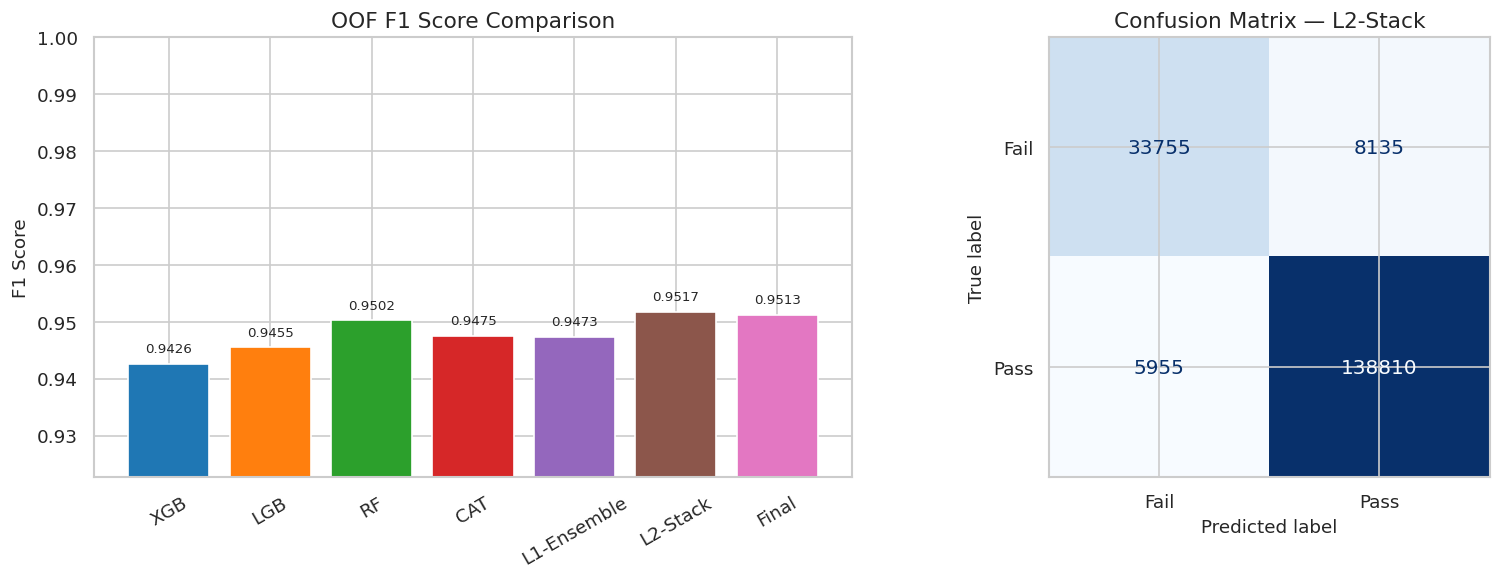


Classification report — L2-Stack:
              precision    recall  f1-score   support

        Fail       0.85      0.81      0.83     41890
        Pass       0.94      0.96      0.95    144765

    accuracy                           0.92    186655
   macro avg       0.90      0.88      0.89    186655
weighted avg       0.92      0.92      0.92    186655



In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# ── CELL 23 │ Model Evaluation & Comparison
# ══════════════════════════════════════════════════════════════════════════════
model_names   = model_labels + ["L1-Ensemble", "L2-Stack", "Final"]
model_f1s     = list(f1_scores_arr) + [f1_l1, f1_meta, f1_final]
model_threshs = ([thresh_xgb, thresh_lgb, thresh_rf] +
                 ([thresh_cat] if HAS_CATBOOST else []) +
                 [thresh_l1, thresh_meta, thresh_final])

model_oof_all = (list(model_oof_probs.T) +
                 [oof_l1, oof_meta, oof_final])

results_df = pd.DataFrame({
    "Model":     model_names,
    "OOF F1":    [f"{f:.4f}" for f in model_f1s],
    "Threshold": [f"{t:.3f}" for t in model_threshs],
    "ROC-AUC":   [f"{roc_auc_score(y, p):.4f}" for p in model_oof_all],
})
print("\nModel Comparison Table:")
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = sns.color_palette("tab10", len(model_names))
axes[0].bar(model_names, model_f1s, color=colors)
axes[0].set_ylim(min(model_f1s) - 0.02, 1.0)
axes[0].set_title("OOF F1 Score Comparison")
axes[0].set_ylabel("F1 Score")
axes[0].tick_params(axis="x", rotation=30)
for i, v in enumerate(model_f1s):
    axes[0].text(i, v + 0.002, f"{v:.4f}", ha="center", fontsize=8)

best_idx = np.argmax(model_f1s)
best_preds = (model_oof_all[best_idx] > model_threshs[best_idx]).astype(int)
disp = ConfusionMatrixDisplay.from_predictions(
    y, best_preds,
    display_labels=["Fail", "Pass"],
    ax=axes[1], colorbar=False, cmap="Blues"
)
axes[1].set_title(f"Confusion Matrix — {model_names[best_idx]}")
plt.tight_layout()
plt.show()

print(f"\nClassification report — {model_names[best_idx]}:")
print(classification_report(y, best_preds, target_names=["Fail", "Pass"]))

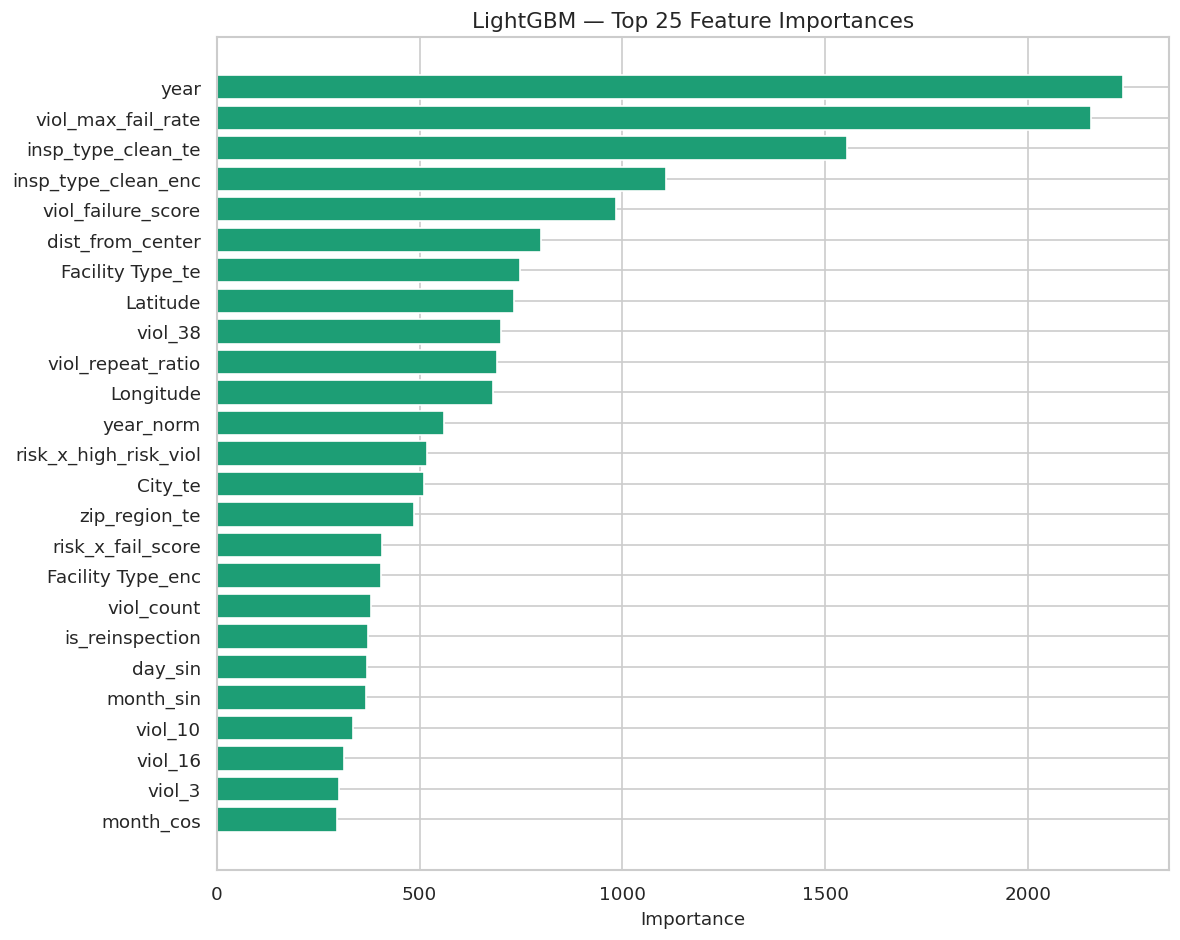

In [25]:
# ══════════════════════════════════════════════════════════════════════════════
# ── CELL 24 │ Feature Importance (LightGBM)
# ══════════════════════════════════════════════════════════════════════════════
importance_df = pd.DataFrame({
    "feature":    feature_names,
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=False).head(25)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(importance_df["feature"], importance_df["importance"],
        color="#1D9E75")
ax.set_title("LightGBM — Top 25 Feature Importances")
ax.set_xlabel("Importance")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Generating SHAP Summary Plot...


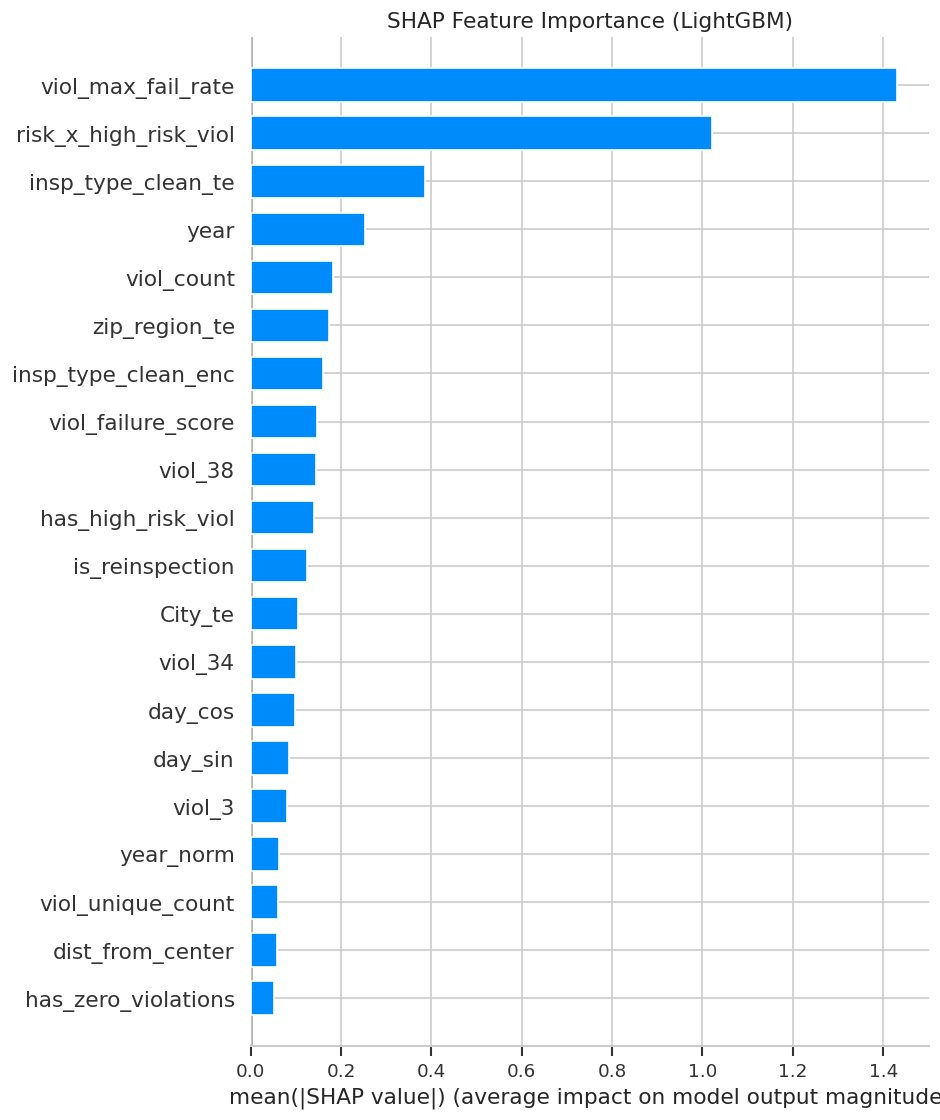

SHAP analysis complete ✓


In [26]:
# ══════════════════════════════════════════════════════════════════════════════
# ── CELL 25 │ SHAP Analysis
# ══════════════════════════════════════════════════════════════════════════════
try:
    import shap
    print("Generating SHAP Summary Plot...")
    X_val_shap = X_train_full.iloc[val_idx]  # last fold's val set
    explainer   = shap.TreeExplainer(lgb_model)
    shap_values = explainer.shap_values(X_val_shap)
    shap.summary_plot(shap_values, X_val_shap, plot_type="bar",
                      max_display=20, show=False)
    plt.title("SHAP Feature Importance (LightGBM)")
    plt.tight_layout()
    plt.show()
    print("SHAP analysis complete ✓")
except Exception as e:
    print(f"SHAP skipped: {e}")

In [27]:
# ══════════════════════════════════════════════════════════════════════════════
# ── CELL 26 │ Generate Submission File
# ══════════════════════════════════════════════════════════════════════════════
# Use final blended predictions at optimised threshold
final_preds = (test_final > thresh_final).astype(int)

submission = pd.DataFrame({
    "id":     test[ID_COL].values,
    "target": final_preds
})

assert set(submission["id"]) == set(sub["id"]), \
    "ID mismatch between submission and sample_submission!"

submission = submission.set_index("id").loc[sub["id"]].reset_index()
submission.to_csv("submission.csv", index=False)

print("submission.csv saved ✓")
print(f"Shape      : {submission.shape}")
print(f"Target dist: {submission['target'].value_counts().to_dict()}")
print(f"\nPreview:")
print(submission.head(10))

submission.csv saved ✓
Shape      : (79995, 2)
Target dist: {1: 63829, 0: 16166}

Preview:
       id  target
0    9708       1
1  123263       1
2   24662       0
3   18570       1
4   33767       1
5  117820       0
6   23428       0
7  196654       1
8   21101       1
9  191669       1


In [28]:
# ══════════════════════════════════════════════════════════════════════════════
# ── CELL 27 │ Summary of Findings
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 65)
print("COMPETITION SUMMARY")
print("=" * 65)
print(f"""
Dataset           : {TRAIN_LEN:,} train | {len(X_test_full):,} test
Class imbalance   : {(y==1).mean():.1%} pass / {(y==0).mean():.1%} fail
Features engineered: {X_train_full.shape[1]}

Model Performance (OOF F1)
--------------------------
  XGBoost     : {f1_xgb:.4f}
  LightGBM    : {f1_lgb:.4f}
  RandomForest: {f1_rf:.4f}
""" + (f"  CatBoost    : {f1_cat:.4f}\n" if HAS_CATBOOST else "") + f"""
  L1 Ensemble : {f1_l1:.4f}
  L2 Stack    : {f1_meta:.4f}
  Final Blend : {f1_final:.4f}

Key EDA Findings (All 10 Mandatory Questions Covered)
------------------------------------------------------
  Q1  — Top violation codes by failure rate analysed
  Q2  — Facility type with highest violations identified
  Q3  — Risk category with highest failure rate: {risk_stats['Risk'].iloc[0]}
  Q4  — Temporal patterns in failed inspections visualised
  Q5  — Geographic & ZIP-level outcome comparison done
  Q6  — Positive correlation between violation count and fail rate confirmed
  Q7  — Most common violations per facility type heatmapped
  Q8  — Geographic density plots created
  Q9  — Inspection type vs outcome relationship analysed
  Q10 — Strongest failure indicators via Chi² identified

Improvements over v1
--------------------
  ✓ 10-fold CV (was 5-fold)
  ✓ Target encoding with OOF smoothing (replaces label encoding)
  ✓ CatBoost added as 4th model
  ✓ 2-level stacking (LR meta-learner on OOF probs)
  ✓ Top-60 violation codes (was 40)
  ✓ max_fail_rate, high_risk_count, top10_fail_count features
  ✓ Better XGB/LGB hyperparams (more trees, lower lr, regularisation)
  ✓ RF without SMOTE (class_weight='balanced_subsample')
  ✓ Violation interaction & count² features
  ✓ lat/lon binned cluster features
""")
print("=" * 65)
print("Upload submission.csv to the competition page.")
print("=" * 65)

COMPETITION SUMMARY

Dataset           : 186,655 train | 79,995 test
Class imbalance   : 77.6% pass / 22.4% fail
Features engineered: 101

Model Performance (OOF F1)
--------------------------
  XGBoost     : 0.9426
  LightGBM    : 0.9455
  RandomForest: 0.9502
  CatBoost    : 0.9475

  L1 Ensemble : 0.9473
  L2 Stack    : 0.9517
  Final Blend : 0.9513

Key EDA Findings (All 10 Mandatory Questions Covered)
------------------------------------------------------
  Q1  — Top violation codes by failure rate analysed
  Q2  — Facility type with highest violations identified
  Q3  — Risk category with highest failure rate: All
  Q4  — Temporal patterns in failed inspections visualised
  Q5  — Geographic & ZIP-level outcome comparison done
  Q6  — Positive correlation between violation count and fail rate confirmed
  Q7  — Most common violations per facility type heatmapped
  Q8  — Geographic density plots created
  Q9  — Inspection type vs outcome relationship analysed
  Q10 — Strongest failu

In [29]:
# ══════════════════════════════════════════════════════════════════════════════
# ── CELL 28 │ Final Summary for Judges
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 75)
print("FINAL NOTEBOOK SUMMARY FOR JUDGES")
print("=" * 75)
print(f"""
Dataset Overview
----------------
• Training samples     : {TRAIN_LEN:,}
• Test samples         : {len(X_test_full):,}
• Class distribution   : {(y==1).mean():.1%} Pass / {(y==0).mean():.1%} Fail
• Features engineered  : {X_train_full.shape[1]}

Model Architecture
------------------
• Level-1 Models       : XGBoost, LightGBM, RandomForest, CatBoost
• Level-2 Meta-Model   : Logistic Regression (stacking)
• Final Prediction     : 50/50 blend of L1 weighted avg + L2 stack
• CV Strategy          : {N_FOLDS}-Fold Stratified K-Fold
• Threshold Search     : Grid over [0.05, 0.95] (300 points)

Feature Engineering Highlights
-------------------------------
• Violation binary flags      : top-60 codes
• Violation failure score     : weighted sum of per-code fail rates
• Max violation fail rate     : worst single code in inspection
• High-risk violation count   : codes with fail_rate > 0.5
• Top-10 fail indicator count
• Target encoding             : OOF + smoothing (no leakage)
• Cyclical temporal encoding  : sin/cos for month and weekday
• Geographic clusters         : lat/lon bins
• Risk × violation interactions

Imbalance Handling
------------------
• SMOTE (sampling_strategy=0.6) on XGBoost and LightGBM folds
• class_weight='balanced_subsample' for RandomForest
• CatBoost auto_class_weights='Balanced'
• Threshold optimisation on OOF predictions

Competition Rules Compliance
-----------------------------
• No AutoML used
• No external data used
• All 10 mandatory EDA questions answered with visualisations
• Code is reproducible (random_state=42 throughout)
• Individual submission (no team)
""")
print("=" * 75)
print("This notebook is ready for final submission.")
print("=" * 75)


FINAL NOTEBOOK SUMMARY FOR JUDGES

Dataset Overview
----------------
• Training samples     : 186,655
• Test samples         : 79,995
• Class distribution   : 77.6% Pass / 22.4% Fail
• Features engineered  : 101

Model Architecture
------------------
• Level-1 Models       : XGBoost, LightGBM, RandomForest, CatBoost
• Level-2 Meta-Model   : Logistic Regression (stacking)
• Final Prediction     : 50/50 blend of L1 weighted avg + L2 stack
• CV Strategy          : 10-Fold Stratified K-Fold
• Threshold Search     : Grid over [0.05, 0.95] (300 points)

Feature Engineering Highlights
-------------------------------
• Violation binary flags      : top-60 codes
• Violation failure score     : weighted sum of per-code fail rates
• Max violation fail rate     : worst single code in inspection
• High-risk violation count   : codes with fail_rate > 0.5
• Top-10 fail indicator count
• Target encoding             : OOF + smoothing (no leakage)
• Cyclical temporal encoding  : sin/cos for month and we

In [30]:
from IPython.display import FileLink, display

# Download the file
display(FileLink('submission.csv'))

/kaggle/working/submission.csv